# 📊 Exploratory Data Analysis — Arabic ASR Project
## Deep Learning Based Arabic Audio Understanding and Retrieval System

---

**Datasets Analyzed:**
- 📁 **Dataset 1:** Arabic Speech Corpus (100 studio-quality MSA sentences)
- 📁 **Dataset 2:** Mozilla Common Voice Arabic (crowd-sourced, diverse speakers)

**Goals of this notebook:**
- Understand the structure and quality of each dataset
- Visualize audio waveforms and spectrograms
- Analyze duration, transcript length, and word distributions
- Identify potential challenges for ASR

---

## 1. 📦 Imports & Setup

In [1]:
!pip install librosa matplotlib seaborn pandas numpy soundfile datasets arabic-reshaper python-bidi --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings
from collections import Counter
from IPython.display import Audio, display
from datasets import load_dataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

print('✅ All libraries loaded')

✅ All libraries loaded


## 2. 📁 Load Datasets

In [3]:
# ── Arabic Speech Corpus ──────────────────────────────────────────────────────
ASC_WAV_DIR    = r"data\arabic_speech\arabic-speech-corpus\arabic-speech-corpus\test set\wav"
ASC_TRANSCRIPT = r"data\arabic_speech\arabic-speech-corpus\arabic-speech-corpus\test set\orthographic-transcript.txt"

asc_refs = {}
with open(ASC_TRANSCRIPT, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split('" "')
            if len(parts) == 2:
                fname = parts[0].replace('"','').strip()
                text  = parts[1].replace('"','').strip()
                asc_refs[fname] = text

asc_files = sorted([f for f in os.listdir(ASC_WAV_DIR) if f.endswith('.wav')])
print(f'✅ Arabic Speech Corpus: {len(asc_files)} audio files, {len(asc_refs)} transcripts')

✅ Arabic Speech Corpus: 100 audio files, 100 transcripts


In [4]:
# ── Build ASC DataFrame ───────────────────────────────────────────────────────
asc_data = []
for fname in asc_files:
    path = os.path.join(ASC_WAV_DIR, fname)
    y, sr = librosa.load(path, sr=None)
    duration = len(y) / sr
    transcript = asc_refs.get(fname, '')
    word_count = len(transcript.split())
    asc_data.append({
        'file': fname, 'duration': duration,
        'sample_rate': sr, 'transcript': transcript,
        'word_count': word_count, 'char_count': len(transcript)
    })

asc_df = pd.DataFrame(asc_data)
print('ASC Dataset Summary:')
print(asc_df[['duration','word_count','char_count']].describe().round(2))

ASC Dataset Summary:
       duration  word_count  char_count
count    100.00      100.00      100.00
mean      10.30       14.00      113.17
std        4.86        6.79       52.92
min        3.08        4.00       35.00
25%        7.02        9.00       75.00
50%        8.95       13.00      103.00
75%       12.57       16.25      133.75
max       28.68       37.00      303.00


In [6]:
# ── Mozilla Common Voice Arabic (Local) ───────────────────────────────────────
import pandas as pd
import librosa

CV_DIR    = r"data\common_voice\1774205751296-cv-corpus-25.0-2026-03-09-ar\cv-corpus-25.0-2026-03-09\ar"
clips_dir = os.path.join(CV_DIR, "clips")
test_tsv  = os.path.join(CV_DIR, "test.tsv")

cv_meta = pd.read_csv(test_tsv, sep='\t')

print('Loading Common Voice Arabic (local, 100 samples)...')
cv_data = []
for i, row in cv_meta.head(100).iterrows():
    audio_path = os.path.join(clips_dir, row['path'])
    if not os.path.exists(audio_path):
        continue
    sentence = row['sentence'].strip()
    y, sr = librosa.load(audio_path, sr=None)
    duration = len(y) / sr
    cv_data.append({
        'sample_id'  : i + 1,
        'sentence'   : sentence,
        'duration'   : duration,
        'sample_rate': sr,
        'word_count' : len(sentence.split()),
        'char_count' : len(sentence),
        'audio_array': y
    })

cv_df = pd.DataFrame(cv_data)
print(f'✅ Common Voice Arabic: {len(cv_df)} samples loaded')
print('CV Dataset Summary:')
print(cv_df[['duration','word_count','char_count']].describe().round(2))

Loading Common Voice Arabic (local, 100 samples)...
✅ Common Voice Arabic: 100 samples loaded
CV Dataset Summary:
       duration  word_count  char_count
count    100.00      100.00      100.00
mean       4.52        4.83       24.79
std        1.31        2.13       14.98
min        2.02        2.00        9.00
25%        3.53        3.00       19.00
50%        4.32        5.00       24.00
75%        5.00        6.00       27.00
max        8.28       14.00      118.00


## 3. 🔊 Audio Waveform & Spectrogram Analysis

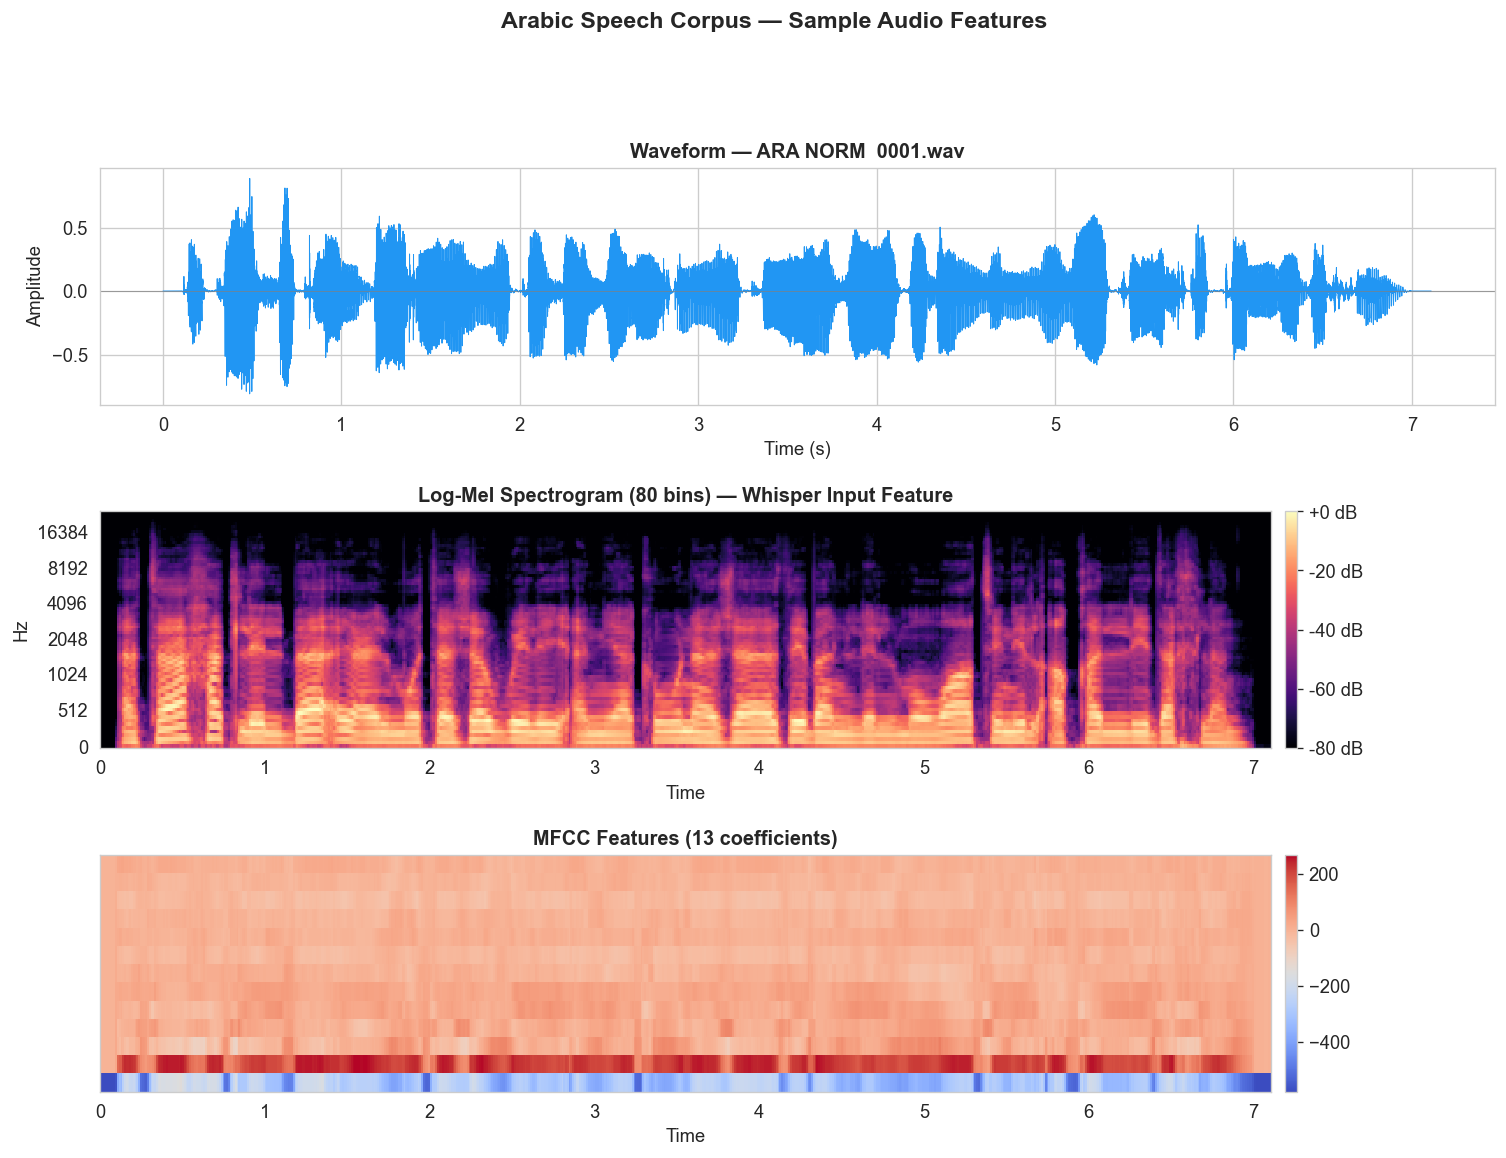

✅ Saved: eda_waveform_asc.png


In [7]:
# ── Waveform + Mel Spectrogram for ASC sample ─────────────────────────────────
sample_path = os.path.join(ASC_WAV_DIR, asc_files[0])
y, sr = librosa.load(sample_path, sr=None)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
mel_db = librosa.power_to_db(mel, ref=np.max)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

ax0 = fig.add_subplot(gs[0])
t = np.linspace(0, len(y)/sr, len(y))
ax0.plot(t, y, color=COLORS[0], linewidth=0.6)
ax0.set_title(f'Waveform — {asc_files[0]}', fontweight='bold', fontsize=12)
ax0.set_xlabel('Time (s)'); ax0.set_ylabel('Amplitude')
ax0.axhline(0, color='gray', linewidth=0.4)

ax1 = fig.add_subplot(gs[1])
img1 = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax1, cmap='magma')
fig.colorbar(img1, ax=ax1, format='%+2.0f dB', pad=0.01)
ax1.set_title('Log-Mel Spectrogram (80 bins) — Whisper Input Feature', fontweight='bold', fontsize=12)

ax2 = fig.add_subplot(gs[2])
img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax2, cmap='coolwarm')
fig.colorbar(img2, ax=ax2, pad=0.01)
ax2.set_title('MFCC Features (13 coefficients)', fontweight='bold', fontsize=12)

plt.suptitle('Arabic Speech Corpus — Sample Audio Features', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_waveform_asc.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: eda_waveform_asc.png')

In [8]:
# ── Play the sample ───────────────────────────────────────────────────────────
print(f'🔊 Playing: {asc_files[0]}')
print(f'   Transcript: {asc_refs.get(asc_files[0], "")}')
display(Audio(sample_path))

🔊 Playing: ARA NORM  0001.wav
   Transcript: >atAHat lilbA}iEi lmutajaw~ili >an yakuwna jA*iban lilmuwATini l>aqal~i daxlan


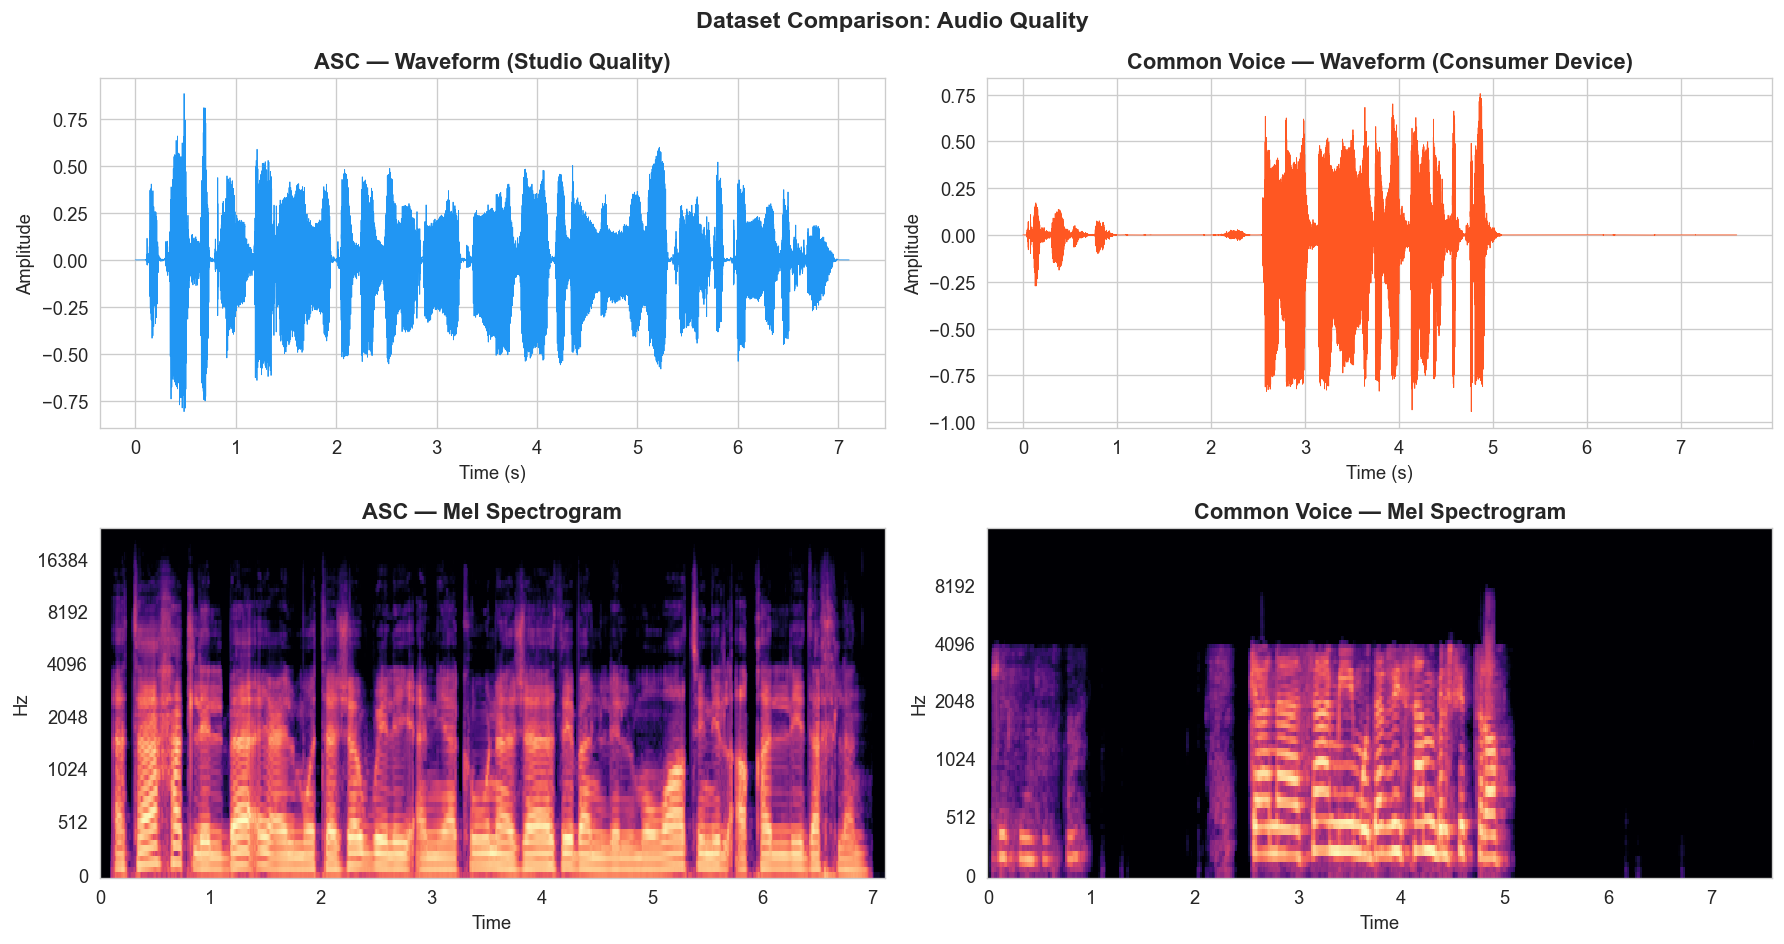

✅ Saved: eda_comparison.png


In [9]:
# ── Compare waveforms: ASC vs Common Voice ────────────────────────────────────
cv_audio = cv_df.iloc[0]['audio_array']
cv_sr = cv_df.iloc[0]['sample_rate']

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ASC waveform
t_asc = np.linspace(0, len(y)/sr, len(y))
axes[0,0].plot(t_asc, y, color=COLORS[0], linewidth=0.5)
axes[0,0].set_title('ASC — Waveform (Studio Quality)', fontweight='bold')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Amplitude')

# CV waveform
t_cv = np.linspace(0, len(cv_audio)/cv_sr, len(cv_audio))
axes[0,1].plot(t_cv, cv_audio, color=COLORS[1], linewidth=0.5)
axes[0,1].set_title('Common Voice — Waveform (Consumer Device)', fontweight='bold')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Amplitude')

# ASC Mel Spectrogram
mel_asc = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
librosa.display.specshow(librosa.power_to_db(mel_asc, ref=np.max),
    sr=sr, x_axis='time', y_axis='mel', ax=axes[1,0], cmap='magma')
axes[1,0].set_title('ASC — Mel Spectrogram', fontweight='bold')

# CV Mel Spectrogram
mel_cv = librosa.feature.melspectrogram(y=cv_audio.astype(float), sr=cv_sr, n_mels=80)
librosa.display.specshow(librosa.power_to_db(mel_cv, ref=np.max),
    sr=cv_sr, x_axis='time', y_axis='mel', ax=axes[1,1], cmap='magma')
axes[1,1].set_title('Common Voice — Mel Spectrogram', fontweight='bold')

plt.suptitle('Dataset Comparison: Audio Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: eda_comparison.png')

## 4. 📈 Duration & Transcript Statistics

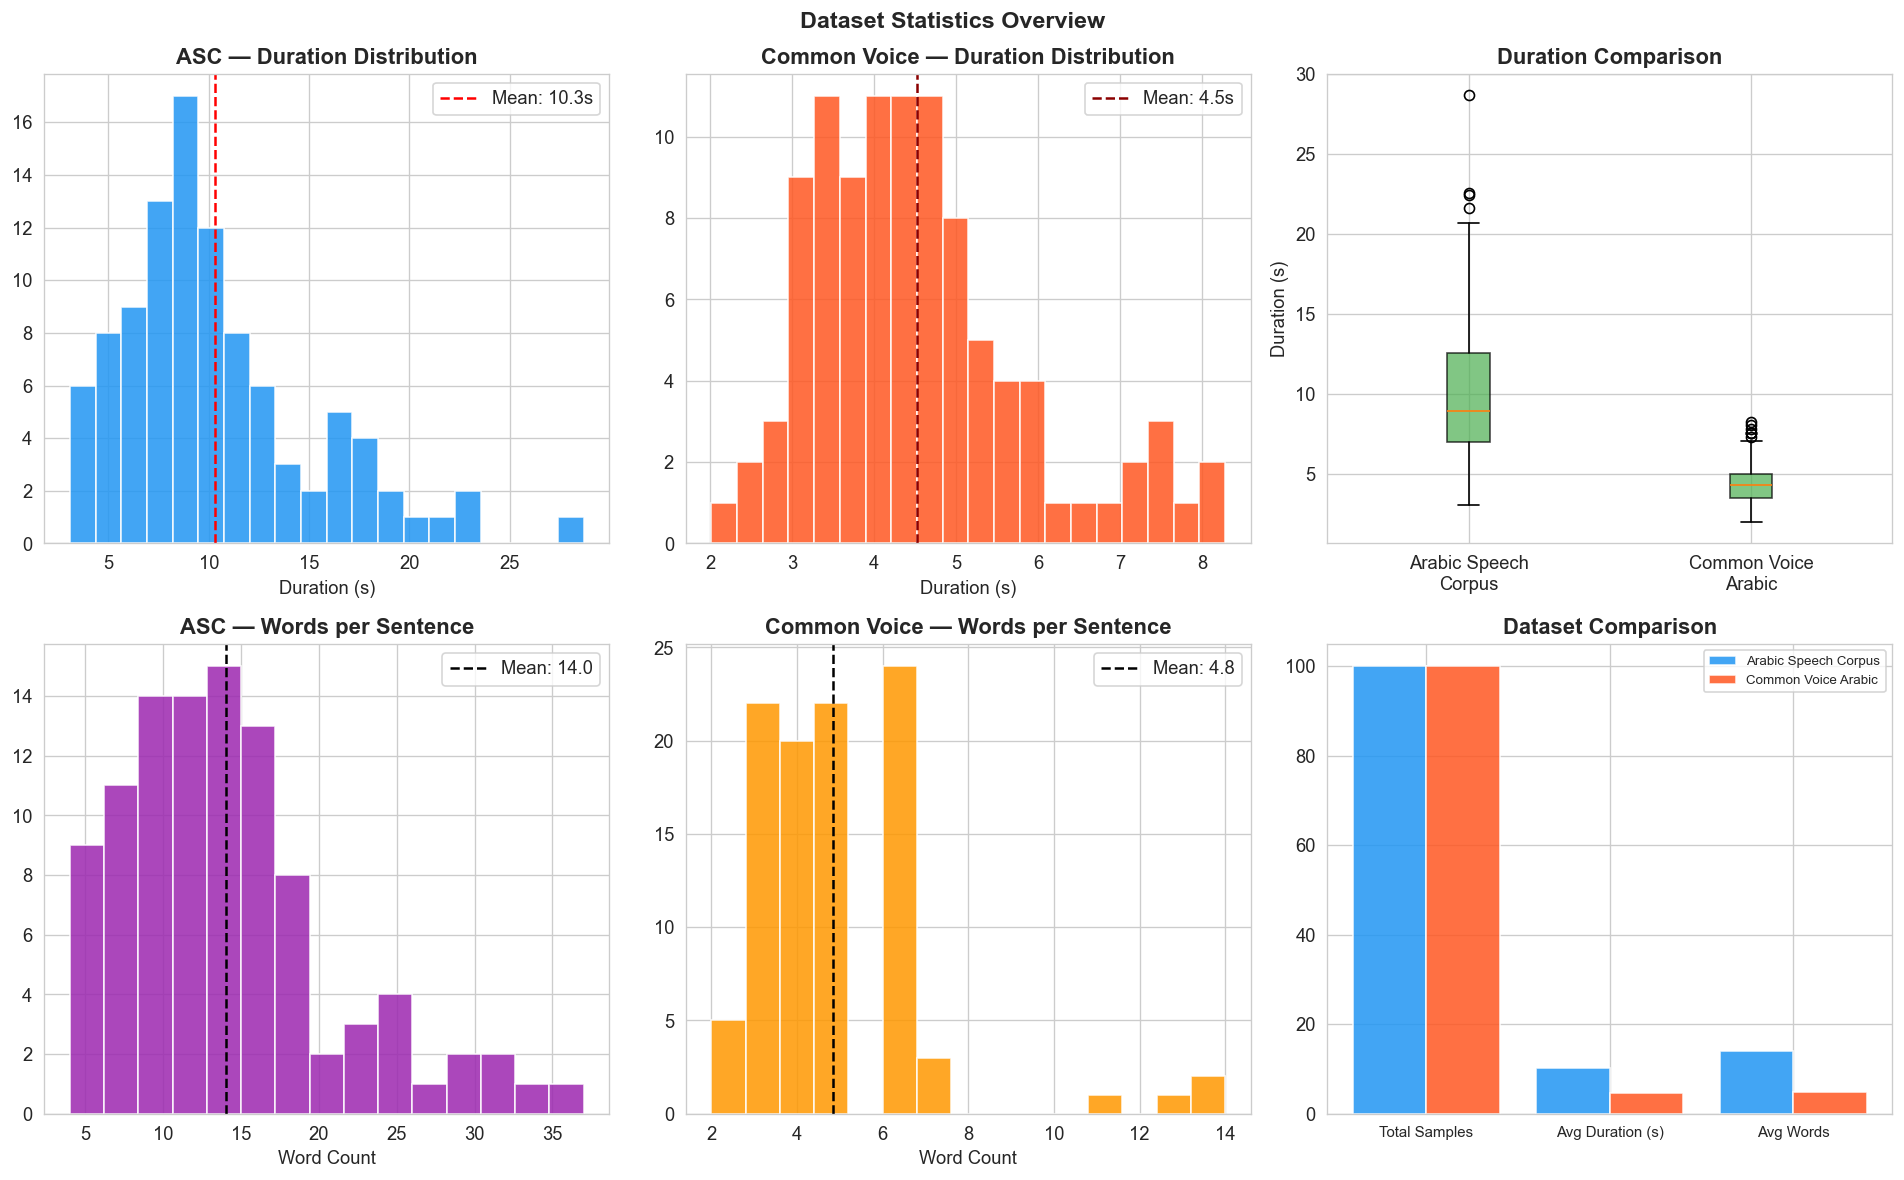

✅ Saved: eda_statistics.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Duration - ASC
axes[0,0].hist(asc_df['duration'], bins=20, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0,0].axvline(asc_df['duration'].mean(), color='red', linestyle='--', linewidth=1.5,
                  label=f"Mean: {asc_df['duration'].mean():.1f}s")
axes[0,0].set_title('ASC — Duration Distribution', fontweight='bold')
axes[0,0].set_xlabel('Duration (s)'); axes[0,0].legend()

# Duration - CV
axes[0,1].hist(cv_df['duration'], bins=20, color=COLORS[1], edgecolor='white', alpha=0.85)
axes[0,1].axvline(cv_df['duration'].mean(), color='darkred', linestyle='--', linewidth=1.5,
                  label=f"Mean: {cv_df['duration'].mean():.1f}s")
axes[0,1].set_title('Common Voice — Duration Distribution', fontweight='bold')
axes[0,1].set_xlabel('Duration (s)'); axes[0,1].legend()

# Duration boxplot comparison
axes[0,2].boxplot([asc_df['duration'], cv_df['duration']],
                  labels=['Arabic Speech\nCorpus', 'Common Voice\nArabic'],
                  patch_artist=True,
                  boxprops=dict(facecolor=COLORS[2], alpha=0.7))
axes[0,2].set_title('Duration Comparison', fontweight='bold')
axes[0,2].set_ylabel('Duration (s)')

# Word count - ASC
axes[1,0].hist(asc_df['word_count'], bins=15, color=COLORS[3], edgecolor='white', alpha=0.85)
axes[1,0].axvline(asc_df['word_count'].mean(), color='black', linestyle='--',
                  label=f"Mean: {asc_df['word_count'].mean():.1f}")
axes[1,0].set_title('ASC — Words per Sentence', fontweight='bold')
axes[1,0].set_xlabel('Word Count'); axes[1,0].legend()

# Word count - CV
axes[1,1].hist(cv_df['word_count'], bins=15, color=COLORS[4], edgecolor='white', alpha=0.85)
axes[1,1].axvline(cv_df['word_count'].mean(), color='black', linestyle='--',
                  label=f"Mean: {cv_df['word_count'].mean():.1f}")
axes[1,1].set_title('Common Voice — Words per Sentence', fontweight='bold')
axes[1,1].set_xlabel('Word Count'); axes[1,1].legend()

# Dataset summary bar chart
metrics = ['Total Samples', 'Avg Duration (s)', 'Avg Words']
asc_vals = [len(asc_df), asc_df['duration'].mean(), asc_df['word_count'].mean()]
cv_vals  = [len(cv_df),  cv_df['duration'].mean(),  cv_df['word_count'].mean()]
x = np.arange(len(metrics))
axes[1,2].bar(x - 0.2, asc_vals, 0.4, label='Arabic Speech Corpus', color=COLORS[0], alpha=0.85)
axes[1,2].bar(x + 0.2, cv_vals,  0.4, label='Common Voice Arabic',  color=COLORS[1], alpha=0.85)
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(metrics, fontsize=9)
axes[1,2].set_title('Dataset Comparison', fontweight='bold')
axes[1,2].legend(fontsize=8)

plt.suptitle('Dataset Statistics Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_statistics.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: eda_statistics.png')

## 5. 🔤 Word Frequency Analysis

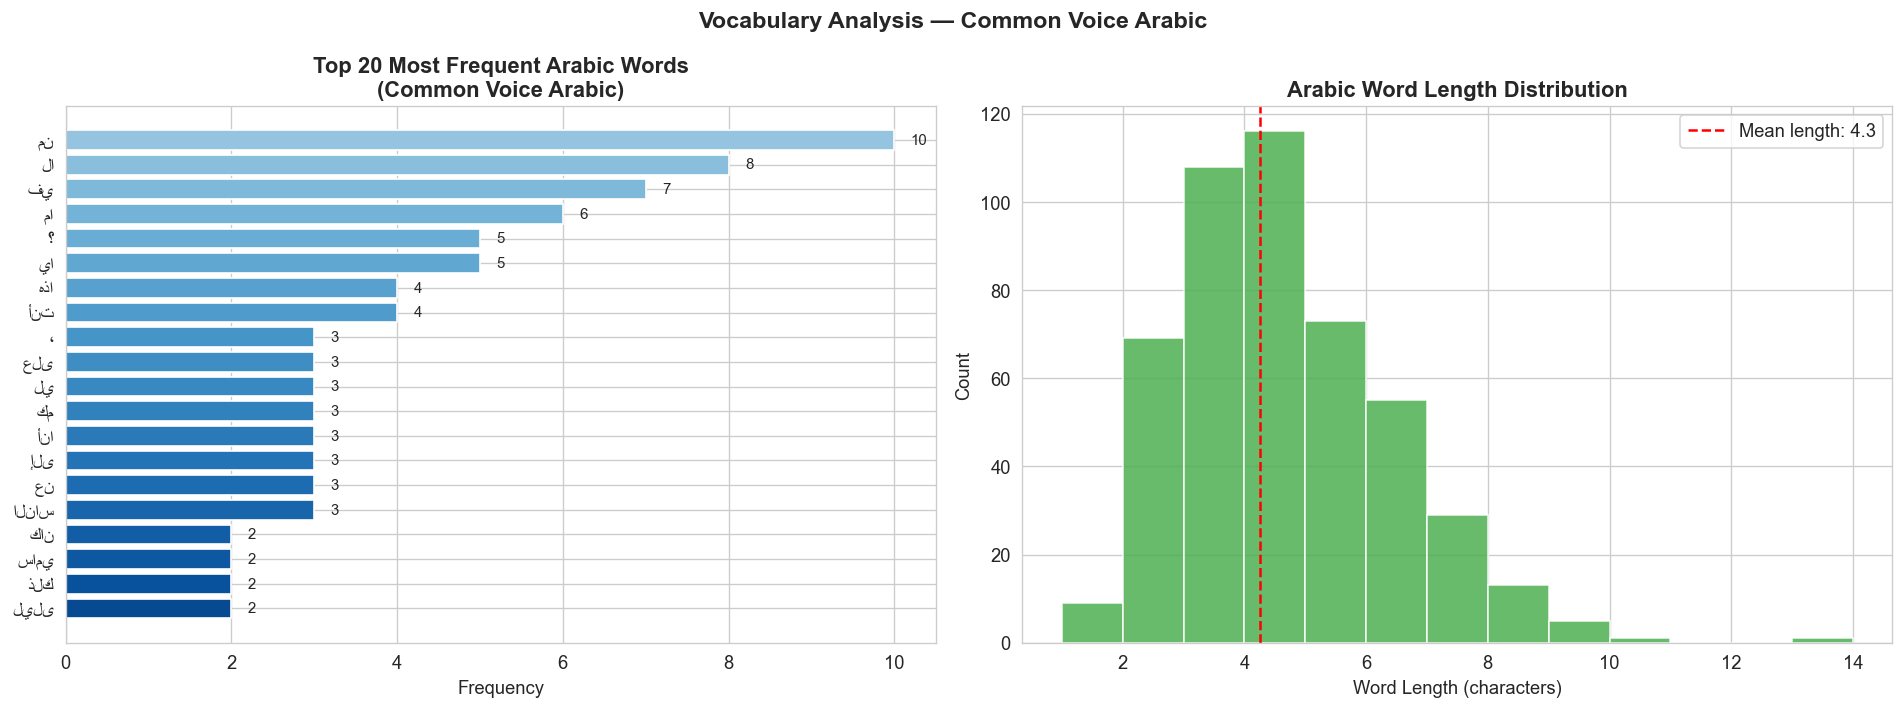


📊 Vocabulary Stats:
   Total words    : 482
   Unique words   : 397
   Avg word length: 4.3 characters
✅ Saved: eda_word_freq.png


In [11]:
# Word frequency analysis on Common Voice (has Arabic script)
all_words = []
for sent in cv_df['sentence']:
    words = re.findall(r'[\u0600-\u06FF]+', sent)
    all_words.extend(words)

word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

words_ar, counts = zip(*top_words)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 words bar chart
y_pos = np.arange(len(words_ar))
bars = axes[0].barh(y_pos, counts, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(counts))))
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(words_ar, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Most Frequent Arabic Words\n(Common Voice Arabic)', fontweight='bold')
axes[0].set_xlabel('Frequency')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontsize=9)

# Word length distribution
word_lengths = [len(w) for w in all_words]
axes[1].hist(word_lengths, bins=range(1, 15), color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(word_lengths), color='red', linestyle='--',
                label=f'Mean length: {np.mean(word_lengths):.1f}')
axes[1].set_title('Arabic Word Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Length (characters)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Vocabulary Analysis — Common Voice Arabic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_word_freq.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n📊 Vocabulary Stats:')
print(f'   Total words    : {len(all_words)}')
print(f'   Unique words   : {len(word_freq)}')
print(f'   Avg word length: {np.mean(word_lengths):.1f} characters')
print('✅ Saved: eda_word_freq.png')

## 6. 🎵 Signal Quality Analysis

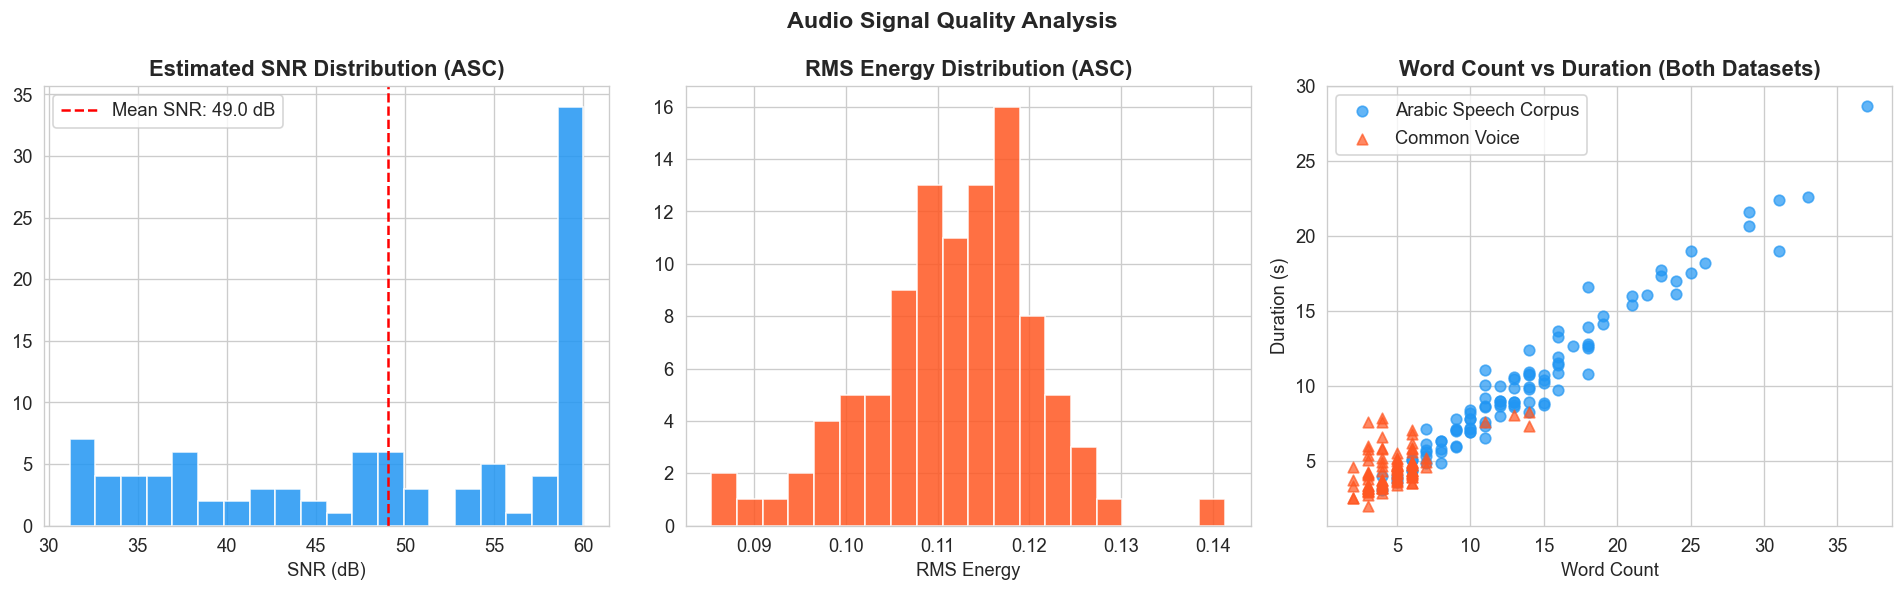


📊 Signal Quality (ASC):
   Mean SNR  : 49.0 dB  (> 20 dB = good quality)
   Mean RMS  : 0.1116
✅ Saved: eda_quality.png


In [12]:
# SNR estimation for ASC dataset
def estimate_snr(y):
    signal_power = np.mean(y**2)
    noise_floor = np.percentile(np.abs(y), 10)**2
    if noise_floor == 0:
        return 60.0
    snr = 10 * np.log10(signal_power / (noise_floor + 1e-10))
    return min(snr, 60.0)

snr_values = []
rms_values = []
for fname in asc_files:
    path = os.path.join(ASC_WAV_DIR, fname)
    y_s, _ = librosa.load(path, sr=None)
    snr_values.append(estimate_snr(y_s))
    rms_values.append(librosa.feature.rms(y=y_s).mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(snr_values, bins=20, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(snr_values), color='red', linestyle='--',
                label=f'Mean SNR: {np.mean(snr_values):.1f} dB')
axes[0].set_title('Estimated SNR Distribution (ASC)', fontweight='bold')
axes[0].set_xlabel('SNR (dB)'); axes[0].legend()

axes[1].hist(rms_values, bins=20, color=COLORS[1], edgecolor='white', alpha=0.85)
axes[1].set_title('RMS Energy Distribution (ASC)', fontweight='bold')
axes[1].set_xlabel('RMS Energy')

# ASC vs CV duration scatter
axes[2].scatter(asc_df['word_count'], asc_df['duration'], alpha=0.7,
                color=COLORS[0], label='Arabic Speech Corpus', s=40)
axes[2].scatter(cv_df['word_count'], cv_df['duration'], alpha=0.7,
                color=COLORS[1], label='Common Voice', s=40, marker='^')
axes[2].set_xlabel('Word Count'); axes[2].set_ylabel('Duration (s)')
axes[2].set_title('Word Count vs Duration (Both Datasets)', fontweight='bold')
axes[2].legend()

plt.suptitle('Audio Signal Quality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_quality.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n📊 Signal Quality (ASC):')
print(f'   Mean SNR  : {np.mean(snr_values):.1f} dB  (> 20 dB = good quality)')
print(f'   Mean RMS  : {np.mean(rms_values):.4f}')
print('✅ Saved: eda_quality.png')

## 7. 📋 EDA Summary

In [13]:
summary = pd.DataFrame({
    'Metric': [
        'Total Samples', 'Total Duration (min)', 'Avg Duration (s)',
        'Min Duration (s)', 'Max Duration (s)',
        'Avg Words/Sentence', 'Avg Chars/Sentence',
        'Sample Rate (Hz)', 'Audio Quality'
    ],
    'Arabic Speech Corpus': [
        len(asc_df),
        f"{asc_df['duration'].sum()/60:.1f}",
        f"{asc_df['duration'].mean():.2f}",
        f"{asc_df['duration'].min():.2f}",
        f"{asc_df['duration'].max():.2f}",
        f"{asc_df['word_count'].mean():.1f}",
        f"{asc_df['char_count'].mean():.1f}",
        '16,000',
        'Studio (High SNR)'
    ],
    'Common Voice Arabic': [
        len(cv_df),
        f"{cv_df['duration'].sum()/60:.1f}",
        f"{cv_df['duration'].mean():.2f}",
        f"{cv_df['duration'].min():.2f}",
        f"{cv_df['duration'].max():.2f}",
        f"{cv_df['word_count'].mean():.1f}",
        f"{cv_df['char_count'].mean():.1f}",
        '48,000',
        'Consumer (Variable)'
    ]
})

print('='*65)
print('           EDA FINAL SUMMARY')
print('='*65)
display(summary)
summary.to_csv('eda_summary.csv', index=False)
print('\n✅ EDA complete! All figures saved.')
print('   → Next: Open main.ipynb for transcription and evaluation')

           EDA FINAL SUMMARY


,Metric,Arabic Speech Corpus,Common Voice Arabic
0,Total Samples,100,100
1,Total Duration (min),17.2,7.5
2,Avg Duration (s),10.30,4.52
3,Min Duration (s),3.08,2.02
4,Max Duration (s),28.68,8.28
5,Avg Words/Sentence,14.0,4.8
6,Avg Chars/Sentence,113.2,24.8
7,Sample Rate (Hz),"16,000","48,000"
8,Audio Quality,Studio (High SNR),Consumer (Variable)



✅ EDA complete! All figures saved.
   → Next: Open main.ipynb for transcription and evaluation
